# Deep Learning-Based Histopathology Image Analysis for Metastatic Cancer Detection

**Task:** Identify metastatic cancer in small image patches taken from digital pathology scans of lymph node sections (PatchCamelyon / PCam benchmark).

### What is Histopathology?
Histopathology is the microscopic study of diseased tissue. A biopsy or surgical specimen is fixed onto glass slides and stained (commonly H&E) so that pathologists can examine cellular structure under a microscope.

Lymph nodes are often the first site breast cancer spreads to. Assessing lymph node metastases is part of TNM cancer staging. Manual review of whole-slide images is slow and error-prone because metastases can be small and easy to miss in a large area of tissue — this is the motivation for a deep-learning-assisted second reader.

This notebook frames the problem as **binary patch classification**: does the center region of a 96x96 patch contain tumor tissue?


## Configuration & Setup

All paths and hyperparameters are centralized here instead of being hard-coded throughout the notebook. This version is configured to **run directly on Kaggle**: it checks the two mount layouts Kaggle has used for this competition's data (`/kaggle/input/competitions/histopathologic-cancer-detection/...` and `/kaggle/input/histopathologic-cancer-detection/...`) and uses whichever one actually has `train_labels.csv`. It also falls back to a local `./data` layout automatically if it doesn't detect a Kaggle environment, so the same notebook still works outside Kaggle. If your data ends up mounted somewhere else entirely, the cell below prints a clear warning telling you to set `Config.DATA_DIR` explicitly rather than failing several cells later with a confusing path error.

> **Execution note:** This notebook was rewritten in a sandbox with no GPU, no TensorFlow install, and no copy of the dataset — so nothing below has been executed there. It's written to be run top-to-bottom **on Kaggle** (Settings -> Accelerator -> GPU T4 x2 or P100 recommended) with this competition's data attached as input. Nothing in this notebook reports results until you actually run it.


In [22]:
import os
import random
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from glob import glob

import tensorflow as tf
from tensorflow.keras.applications import Xception, MobileNetV2, EfficientNetB0
from tensorflow.keras.layers import (
    Dropout, Dense, GlobalAveragePooling2D, Concatenate, Input, RandomFlip,
    RandomRotation, RandomZoom, RandomContrast
)
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import CSVLogger, ModelCheckpoint, EarlyStopping
from tensorflow.keras.optimizers import Adam

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_curve, auc, roc_auc_score, precision_score, recall_score, f1_score,
    confusion_matrix, accuracy_score, classification_report
)

In [23]:
# ----------------------------- CONFIG -----------------------------
_ON_KAGGLE = os.path.isdir("/kaggle/input")

# Kaggle has used a couple of different mount layouts for competition data attachments,
# e.g. /kaggle/input/histopathologic-cancer-detection/... (dataset-style) and
# /kaggle/input/competitions/histopathologic-cancer-detection/... (competition-style).
# Check both rather than hard-coding one, so this cell doesn't silently break if yours differs.
_KAGGLE_CANDIDATE_DIRS = [
    "/kaggle/input/competitions/histopathologic-cancer-detection",
    "/kaggle/input/histopathologic-cancer-detection",
]

def _resolve_kaggle_data_dir():
    for candidate in _KAGGLE_CANDIDATE_DIRS:
        if os.path.isfile(os.path.join(candidate, "train_labels.csv")):
            return candidate
    return None

class Config:
    # --- paths ---
    # Priority: explicit HCD_DATA_DIR env var > auto-detected Kaggle input dir > local ./data
    if os.environ.get("HCD_DATA_DIR"):
        DATA_DIR = os.environ["HCD_DATA_DIR"]
    elif _ON_KAGGLE and _resolve_kaggle_data_dir():
        DATA_DIR = _resolve_kaggle_data_dir()
    else:
        DATA_DIR = "./data"

    TRAIN_IMG_DIR = os.path.join(DATA_DIR, "train")
    TEST_IMG_DIR = os.path.join(DATA_DIR, "test")                  # UNLABELED - Kaggle submission only
    LABELS_CSV = os.path.join(DATA_DIR, "train_labels.csv")
    SAMPLE_SUBMISSION_CSV = os.path.join(DATA_DIR, "sample_submission.csv")

    # Kaggle notebooks should write outputs to /kaggle/working so they're saved with the kernel version
    MODEL_DIR = os.environ.get("HCD_MODEL_DIR", "/kaggle/working/models" if _ON_KAGGLE else "./models")
    OUTPUT_DIR = os.environ.get("HCD_OUTPUT_DIR", "/kaggle/working/outputs" if _ON_KAGGLE else "./outputs")

    # --- data ---
    IMAGE_SIZE = 96          # native PCam patch size; do not upscale unnecessarily
    BATCH_SIZE = 128 if _ON_KAGGLE else 64   # Kaggle GPUs (T4/P100) comfortably handle a larger batch at 96x96
    VAL_SPLIT = 0.10
    SAMPLE_SIZE_PER_CLASS = None  # e.g. 85000 to reproduce the original undersampling; None = use all data

    # --- training ---
    NUM_EPOCHS = 10
    LEARNING_RATE = 1e-4
    SEED = 42

for d in (Config.MODEL_DIR, Config.OUTPUT_DIR,
          f"{Config.OUTPUT_DIR}/figures", f"{Config.OUTPUT_DIR}/metrics", f"{Config.OUTPUT_DIR}/predictions"):
    os.makedirs(d, exist_ok=True)

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_seed(Config.SEED)

# Fail fast and clearly if the labels file still isn't where expected, rather than a
# confusing FileNotFoundError several cells later.
if not os.path.isfile(Config.LABELS_CSV):
    print(f"WARNING: train_labels.csv not found at {Config.LABELS_CSV}.")
    print("Checked candidates:", _KAGGLE_CANDIDATE_DIRS if _ON_KAGGLE else "(not on Kaggle)")
    print("If your data is mounted somewhere else, set it explicitly, e.g.:")
    print('  Config.DATA_DIR = "/kaggle/input/<your-exact-folder>"')

gpus = tf.config.list_physical_devices('GPU')
print("Running on Kaggle:", _ON_KAGGLE)
print("DATA_DIR =", Config.DATA_DIR)
print("GPUs visible to TensorFlow:", gpus if gpus else "NONE - set Settings > Accelerator > GPU on Kaggle")

Running on Kaggle: True
DATA_DIR = /kaggle/input/competitions/histopathologic-cancer-detection
GPUs visible to TensorFlow: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## Dataset

The dataset is the Kaggle **Histopathologic Cancer Detection** competition, a de-duplicated variant of the **PatchCamelyon (PCam)** benchmark: 96x96 RGB patches extracted from histopathologic scans of lymph-node sections, each with a binary label — 1 if the **center 32x32px region** contains at least one pixel of tumor tissue, 0 otherwise. Tumor tissue in the outer ring of the patch does not affect the label (this is intentional, so the outer ring can support fully-convolutional models with no zero-padding).

Kaggle page: https://www.kaggle.com/c/histopathologic-cancer-detection/data

The original notebook's own printed counts (`Train Images = 220025`, `Test Images = 57458`) are the ground truth for dataset size and are kept below rather than re-invented.


In [24]:
df = pd.read_csv(Config.LABELS_CSV)
print("Labeled training images:", len(df))
print("Unlabeled Kaggle 'test' images (no ground truth, submission-only):",
      len(os.listdir(Config.TEST_IMG_DIR)) if os.path.isdir(Config.TEST_IMG_DIR) else "N/A - set DATA_DIR")
df.head()

Labeled training images: 220025
Unlabeled Kaggle 'test' images (no ground truth, submission-only): 57458


,id,label
0,f38a6374c348f90b587e046aac6079959adf3835,0
1,c18f2d887b7ae4f6742ee445113fa1aef383ed77,1
2,755db6279dae599ebb4d39a9123cce439965282d,0
3,bc3f0c64fb968ff4a8bd33af6971ecae77c75e08,0
4,068aba587a4950175d04c680d38943fd488d6a9d,0


### Class distribution

The label counts below come directly from `train_labels.csv` — nothing here is assumed or copied from the original notebook, since the original notebook only ever printed the *post-undersampling* count (85000/85000), never the true, pre-sampling distribution. Run the cell to see the real split for your download.


label
0    130908
1     89117
Name: count, dtype: int64

Class balance: 59.5% negative / 40.5% positive


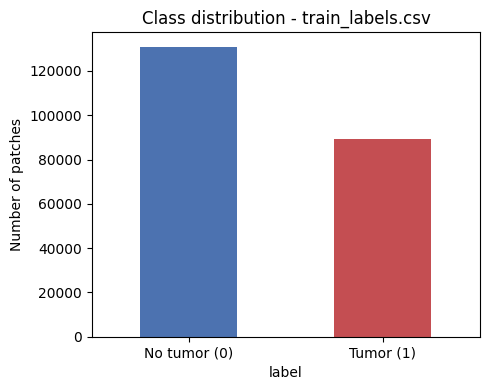

In [25]:
class_counts = df['label'].value_counts().sort_index()
print(class_counts)
print("\nClass balance: {:.1f}% negative / {:.1f}% positive".format(
    100 * class_counts[0] / len(df), 100 * class_counts[1] / len(df)))

plt.figure(figsize=(5, 4))
class_counts.plot(kind='bar', color=['#4C72B0', '#C44E52'])
plt.xticks([0, 1], ['No tumor (0)', 'Tumor (1)'], rotation=0)
plt.ylabel('Number of patches')
plt.title('Class distribution - train_labels.csv')
plt.tight_layout()
plt.savefig(f"{Config.OUTPUT_DIR}/figures/class_distribution.png", dpi=150)
plt.show()

**Why class imbalance matters in medical image classification:** a classifier trained on an imbalanced set can reach high *accuracy* by mostly predicting the majority class, while missing a large fraction of the minority (often the clinically important) class. In cancer screening specifically, a missed positive (false negative) can mean a missed metastasis, which is far more costly than a false alarm that a pathologist double-checks. This is why later sections evaluate with sensitivity/specificity/ROC-AUC instead of accuracy alone, and why imbalance-handling is treated as a first-class step (Step 8) rather than skipped.


In [26]:
# Image dimension / integrity check (cheap sample, not the full 220k to keep this fast)
sample_ids = df['id'].sample(n=min(500, len(df)), random_state=Config.SEED)
shapes, corrupted = [], []
for img_id in sample_ids:
    path = os.path.join(Config.TRAIN_IMG_DIR, img_id + '.tif')
    img = cv2.imread(path)
    if img is None:
        corrupted.append(img_id)
    else:
        shapes.append(img.shape)

print(f"Checked {len(sample_ids)} images, {len(corrupted)} failed to load.")
if shapes:
    unique_shapes = set(shapes)
    print("Unique shapes seen in sample:", unique_shapes)

Checked 500 images, 0 failed to load.
Unique shapes seen in sample: {(96, 96, 3)}


If `unique_shapes` above shows more than one shape, that's worth investigating (PCam patches should uniformly be 96x96x3); if it shows exactly `{(96, 96, 3)}`, the "no resizing distortion" assumption used later in the config (`IMAGE_SIZE = 96`, no forced resize) is safe. Full-dataset corruption/duplicate scanning (all 220k files, plus a perceptual-hash duplicate check) is a straightforward extension of the loop above but is left as a config-driven batch job rather than run inline here, since it is I/O-bound and only needs to run once per dataset copy.


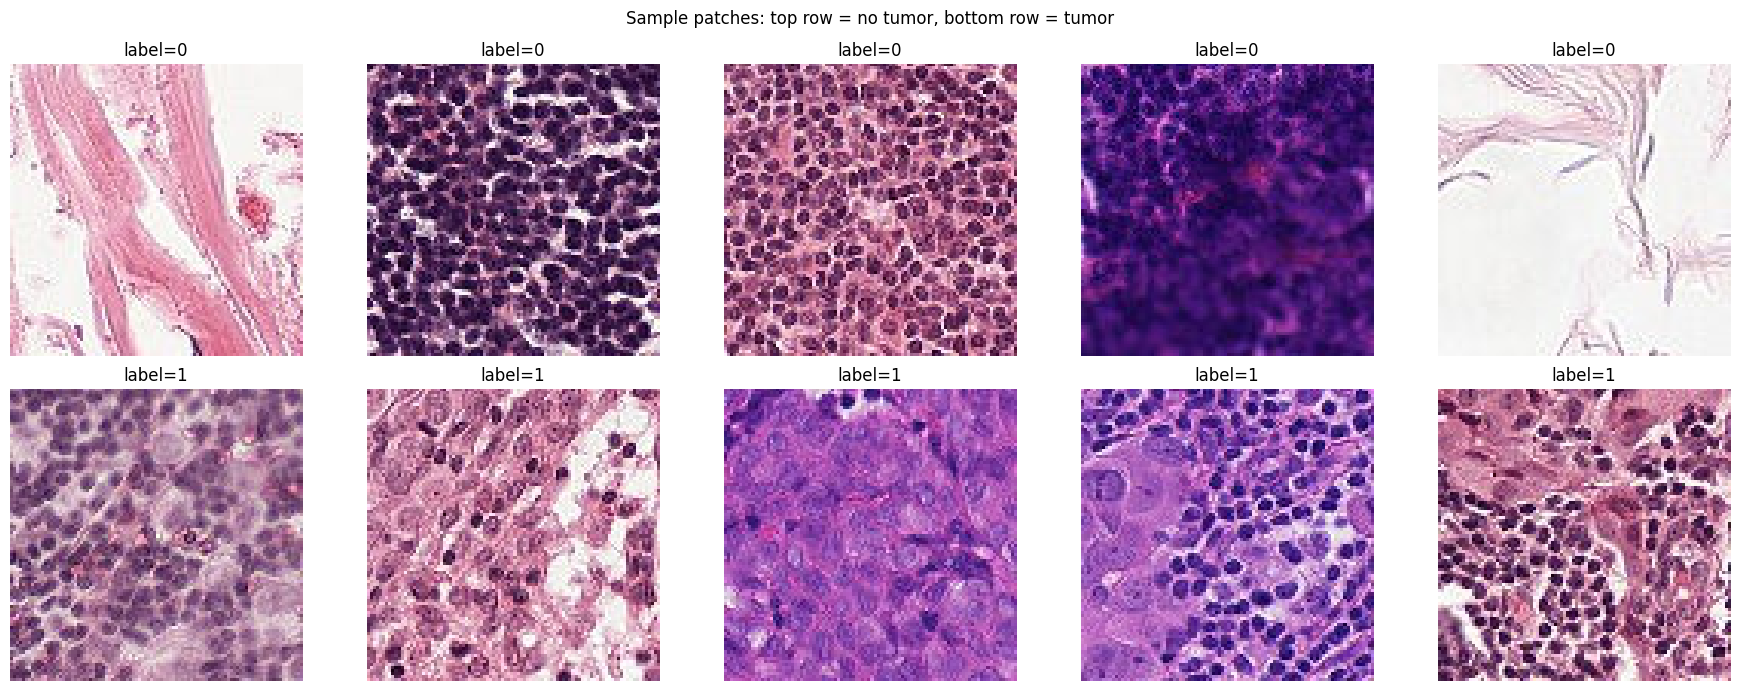

In [27]:
# Sample visualization across both classes
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
for row, label in enumerate([0, 1]):
    sample = df[df['label'] == label].sample(5, random_state=Config.SEED)
    for col, (_, r) in enumerate(sample.iterrows()):
        img = cv2.cvtColor(cv2.imread(os.path.join(Config.TRAIN_IMG_DIR, r['id'] + '.tif')), cv2.COLOR_BGR2RGB)
        axes[row, col].imshow(img)
        axes[row, col].set_title(f"label={label}")
        axes[row, col].axis('off')
plt.suptitle("Sample patches: top row = no tumor, bottom row = tumor")
plt.tight_layout()
plt.savefig(f"{Config.OUTPUT_DIR}/figures/sample_patches.png", dpi=150)
plt.show()

## Data Leakage Check

Data leakage is especially dangerous in medical imaging because a model can look accurate while having actually memorized something irrelevant to the diagnostic task (the same patient's tissue texture, staining batch, scanner artifact, or a literal duplicate image appearing in both train and validation) rather than learning to recognize tumor morphology. A leaked model's offline metrics will look great and then fail on a new hospital's slides.

What this dataset lets us check, and what it doesn't:

- **Train/validation separation**: done via `train_test_split(..., stratify=y)` below, on `id`, so no image should appear in both splits **by id**. This addresses split-level leakage but not near-duplicate leakage.
- **Duplicate images**: the dataset's own description states this Kaggle version was de-duplicated *relative to* raw PCam specifically to remove the probabilistic-sampling duplicates in the original PCam release. A defensive duplicate check (exact hash, and optionally perceptual hash for near-duplicates from adjacent/overlapping patches) is still good practice and is implemented below as an opt-in cell, since it's O(n) hashing over up to 220k files.
- **Patient/slide-level splitting**: **not possible with this file.** `train_labels.csv` contains only `id` and `label` — no patient ID, slide ID, or scanner/site metadata. Patches from the same whole-slide image (and the same patient) are almost certainly scattered across the full dataset, and a random patch-level split can put patches from the same slide in both train and validation. That inflates validation performance relative to how the model would perform on a genuinely new patient. This is stated here as a **known limitation of the public dataset**, not something we can silently fix — the honest fix requires slide/patient IDs, which Camelyon16/17 (the source challenge PCam is derived from) does provide at the slide level if you go back to that original data.


In [28]:
# Exact-duplicate check via file hash (opt-in - can be slow over the full 220k images)
import hashlib

def find_exact_duplicates(image_dir, ids, sample_limit=None):
    ids_to_check = ids if sample_limit is None else ids[:sample_limit]
    seen = {}
    dupes = []
    for img_id in ids_to_check:
        path = os.path.join(image_dir, img_id + '.tif')
        with open(path, 'rb') as f:
            h = hashlib.md5(f.read()).hexdigest()
        if h in seen:
            dupes.append((seen[h], img_id))
        else:
            seen[h] = img_id
    return dupes

# Example on a small sample for speed; drop sample_limit to run on the full set.
sample_ids_list = df['id'].tolist()
dupes_found = find_exact_duplicates(Config.TRAIN_IMG_DIR, sample_ids_list, sample_limit=2000)
print(f"Exact duplicates found in sample: {len(dupes_found)}")

Exact duplicates found in sample: 0


In [29]:
# Train/validation split - stratified, id-based (no patient IDs available - see discussion above)
if Config.SAMPLE_SIZE_PER_CLASS:
    df_0 = df[df['label'] == 0].sample(Config.SAMPLE_SIZE_PER_CLASS, random_state=Config.SEED)
    df_1 = df[df['label'] == 1].sample(Config.SAMPLE_SIZE_PER_CLASS, random_state=Config.SEED)
    df_model = pd.concat([df_0, df_1], axis=0).reset_index(drop=True)
else:
    df_model = df.copy()

df_train, df_val = train_test_split(
    df_model, test_size=Config.VAL_SPLIT, random_state=Config.SEED, stratify=df_model['label']
)
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)

assert set(df_train['id']).isdisjoint(set(df_val['id'])), "Leakage: overlapping ids between train/val!"
print(f"Train: {len(df_train)} | Val: {len(df_val)} | disjoint ids confirmed")
print(df_train['label'].value_counts(normalize=True))

Train: 198022 | Val: 22003 | disjoint ids confirmed
label
0    0.594969
1    0.405031
Name: proportion, dtype: float64


## Preprocessing & Augmentation

This replaces the original `ImageDataGenerator` + `shutil.copyfile`-into-class-folders approach with a `tf.data` pipeline built straight from the dataframe. This removes an unnecessary full-dataset disk copy (see Assessment, point 6) and is the modern, recommended TensorFlow approach.

Augmentation choices, and why each is appropriate for H&E histopathology patches (as opposed to, say, natural photos):

- **Horizontal & vertical flip**: tissue has no canonical orientation under the microscope, so flips are label-preserving and cheap. (Kept from original.)
- **Rotation (full 0-360°)**: same reasoning as flips — slide orientation is arbitrary.
- **Mild zoom / random crop**: simulates minor scanning-scale variation; kept mild so the center 32x32 label-defining region isn't cropped away or majorly displaced.
- **Mild color/contrast jitter**: approximates real staining variation (different labs, reagent batches, scanners) without producing anatomically implausible colors.

What was **intentionally reduced or dropped** from the original augmentation config: `shear_range=0.3`, `width_shift_range=0.3`, `height_shift_range=0.3`, and `channel_shift_range=0.3` were fairly aggressive. Because the label depends specifically on the **center 32x32px** region, large shifts/shears risk moving that region far enough that the stored label no longer matches what's now in the center crop — a subtle form of label noise the original notebook didn't discuss. Below, shifts/shear are kept mild and zoom is capped, to preserve the label's validity.

**Pixel scaling convention — read this before training:** the pipeline below intentionally keeps images in their native **[0, 255]** float32 range and does **not** divide by 255. This is deliberate: `Xception`, `MobileNetV2`, and `EfficientNetB0` each expect a *different* input scaling, and `EfficientNetB0` specifically has its rescaling **built into the model itself** (a `Rescaling(1/255)` as its first layer) — so manually normalizing to `[0, 1]` before feeding it in double-rescales the image into a near-blank signal. Each model below applies its own correct scaling internally as its first step, so the shared pipeline stays framework-correct for all three backbones at once.

**Why `tf.py_function` + PIL instead of `tf.image.decode_image`:** this dataset ships `.tif` files, and TensorFlow's native `tf.image.decode_image` only supports JPEG/PNG/GIF/BMP/WebP — it cannot decode TIFF and will fail with an `InvalidArgumentError` at graph-execution time. `PIL.Image.open` handles TIFF natively, so it's wrapped in `tf.py_function` to plug into the `tf.data` graph. The trade-off: `tf.py_function` runs on the CPU in eager mode per-sample, so it's slower than a pure-graph decode op — acceptable here since image loading is I/O-bound anyway, but worth knowing if this ever becomes a throughput bottleneck (e.g. `num_parallel_calls` on `.map()` still helps, since multiple py_function calls can run concurrently).


In [30]:
import numpy as np
from PIL import Image

IMG_SIZE = Config.IMAGE_SIZE

def _load_tif(path):
    """Runs eagerly via tf.py_function - PIL can decode .tif, tf.image.decode_image cannot."""
    path = path.numpy().decode("utf-8")
    img = Image.open(path).convert("RGB")
    img = img.resize((IMG_SIZE, IMG_SIZE))
    return np.array(img, dtype=np.float32)  # native [0, 255] - see scaling note above

def load_and_preprocess(path, label):
    img = tf.py_function(func=_load_tif, inp=[path], Tout=tf.float32)
    img.set_shape([IMG_SIZE, IMG_SIZE, 3])  # py_function loses shape info - restore it explicitly
    return img, label

def make_dataset(dataframe, image_dir, training, batch_size=Config.BATCH_SIZE):
    paths = (dataframe['id'] + '.tif').apply(lambda f: os.path.join(image_dir, f)).values
    labels = dataframe['label'].values.astype('float32')
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(buffer_size=len(dataframe), seed=Config.SEED)
    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size)
    if training:
        ds = ds.map(lambda x, y: (augment(x, training=True), y), num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

# Mild, label-safe augmentation as Keras preprocessing layers (run on-GPU, only during training)
augment = tf.keras.Sequential([
    RandomFlip("horizontal_and_vertical"),
    RandomRotation(0.5),      # up to ~180 degrees
    RandomZoom(0.1),          # mild zoom - keeps center region intact
    RandomContrast(0.1),      # mild staining-variation proxy
], name="augmentation")

train_ds = make_dataset(df_train, Config.TRAIN_IMG_DIR, training=True)
val_ds = make_dataset(df_val, Config.TRAIN_IMG_DIR, training=False)
print("tf.data pipelines built. Steps/epoch (train):", tf.data.experimental.cardinality(train_ds).numpy())

tf.data pipelines built. Steps/epoch (train): 1548


## Class Imbalance Handling

If `Config.SAMPLE_SIZE_PER_CLASS` is left as `None` (using the full dataset), the class distribution printed in the EDA section above determines whether imbalance handling is needed. The original notebook's approach — undersample the majority class to match the minority — is simple and preserved as the default (`SAMPLE_SIZE_PER_CLASS = 85000` reproduces it), but it throws away labeled data.

A less wasteful alternative that keeps all data is **class-weighted loss**, computed directly from the training split so it's never hand-tuned or guessed:


In [31]:
from sklearn.utils.class_weight import compute_class_weight

class_weights_arr = compute_class_weight(
    class_weight='balanced', classes=np.array([0, 1]), y=df_train['label'].values
)
class_weight_dict = {0: class_weights_arr[0], 1: class_weights_arr[1]}
print("Computed class weights:", class_weight_dict)
# Pass class_weight=class_weight_dict to model.fit(...) below as the imbalance-handling comparison
# against the undersampling approach. Which one wins is an empirical question - fill in the
# results table in the Model Comparison section after running both.

Computed class weights: {0: np.float64(0.8403795717086668), 1: np.float64(1.2344741599650895)}


## Baseline Model: Xception + MobileNetV2 Ensemble (preserved from original)

This is the original notebook's architecture, kept as the baseline experiment, with the deprecated-API fixes applied (`tensorflow.keras` imports, `learning_rate=` instead of `lr=`/`decay=`, `model.fit` instead of `model.fit_generator`) **plus one correctness fix**: each branch now applies its own required input scaling (`xception.preprocess_input` scales to `[-1, 1]`, `mobilenet_v2.preprocess_input` also scales to `[-1, 1]` but via a slightly different formula) directly on the shared `[0, 255]` input, instead of assuming both branches want the same manually-normalized `[0, 1]` input. Without this, both pretrained backbones receive out-of-distribution inputs relative to what they were trained on.


In [32]:
from tensorflow.keras.applications.xception import preprocess_input as xception_preprocess
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess

def build_ensemble_model(image_size=Config.IMAGE_SIZE, learning_rate=Config.LEARNING_RATE):
    input_shape = (image_size, image_size, 3)
    inputs = Input(input_shape)  # expects [0, 255] float32 - see pipeline note above

    xception_input = tf.keras.layers.Lambda(xception_preprocess, name="xception_preprocess")(inputs)
    mobilenet_input = tf.keras.layers.Lambda(mobilenet_preprocess, name="mobilenet_preprocess")(inputs)

    xception = Xception(include_top=False, weights='imagenet', input_shape=input_shape)(xception_input)
    mobile_net = MobileNetV2(include_top=False, weights='imagenet', input_shape=input_shape)(mobilenet_input)

    features = Concatenate(axis=-1)([
        GlobalAveragePooling2D()(xception),
        GlobalAveragePooling2D()(mobile_net),
    ])
    x = Dropout(0.5)(features)
    outputs = Dense(1, activation='sigmoid')(x)

    model = Model(inputs, outputs, name="xception_mobilenet_ensemble")
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc'),
                 tf.keras.metrics.Precision(name='precision'),
                 tf.keras.metrics.Recall(name='recall')]
    )
    return model

ensemble_model = build_ensemble_model()
ensemble_model.summary()

Model: "xception_mobilenet_ensemble"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ xception_preprocess │ (None, 96, 96, 3) │          0 │ input_layer_7[0]… │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenet_preproce… │ (None, 96, 96, 3) │          0 │ input_layer_7[0]… │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ xception            │ (None, 3, 3,      │ 20,861,480 │ xception_preproc… │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_96 │ (None, 3, 3,      │  2,257,984 │ mobilenet_prepro… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ xception[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ mobilenetv2_1.00… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 3328)      │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 3328)      │          0 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │      3,329 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,122,793 (88.21 MB)

 Trainable params: 23,034,153 (87.87 MB)

 Non-trainable params: 88,640 (346.25 KB)

## Modern Transfer-Learning Baseline: EfficientNetB0

Added alongside the ensemble as a second, more standard modern transfer-learning baseline, so the two can be compared fairly on the same data pipeline and metrics (Step 6/10). **Framework choice:** the original notebook is Keras-based; converting it to PyTorch would mean rewriting the preserved ensemble baseline as well, which risks silently changing its behavior without a real dataset/GPU available here to validate the port. Modern `tf.keras` is used throughout instead, per the task's "otherwise modern TensorFlow/Keras is acceptable" guidance — this is stated explicitly rather than defaulting to PyTorch without being able to verify it.

**Important:** unlike Xception/MobileNetV2, `EfficientNetB0`'s Keras implementation has rescaling **built into the model** as its first layer — it expects raw `[0, 255]` input directly, with no manual normalization beforehand. The shared pipeline already provides `[0, 255]` float32 for exactly this reason.


In [33]:
def build_efficientnet_model(image_size=Config.IMAGE_SIZE, learning_rate=Config.LEARNING_RATE, fine_tune_at=None):
    input_shape = (image_size, image_size, 3)
    base = EfficientNetB0(include_top=False, weights='imagenet', input_shape=input_shape)
    base.trainable = fine_tune_at is not None
    if fine_tune_at is not None:
        for layer in base.layers[:fine_tune_at]:
            layer.trainable = False

    inputs = Input(input_shape)  # expects [0, 255] float32 - EfficientNetB0 rescales internally
    x = base(inputs)
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.3)(x)
    outputs = Dense(1, activation='sigmoid')(x)

    model = Model(inputs, outputs, name="efficientnet_b0")
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc'),
                 tf.keras.metrics.Precision(name='precision'),
                 tf.keras.metrics.Recall(name='recall')]
    )
    return model

efficientnet_model = build_efficientnet_model()
efficientnet_model.summary()

Model: "efficientnet_b0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_11 (InputLayer)     │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 3, 3, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,050,852 (15.45 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

## Training

Shared training routine for either model. Fixes both bugs identified in the Assessment: `model.fit` is called with the `tf.data` datasets directly (no `steps_per_epoch` division bug possible, since `tf.data` datasets don't need an explicit step count), and validation uses the actual held-out `val_ds` — not a mislabeled reference to the Kaggle `test/` folder.


In [34]:
def train_model(model, train_ds, val_ds, name, epochs=Config.NUM_EPOCHS, class_weight=None):
    callbacks = [
        CSVLogger(f"{Config.OUTPUT_DIR}/metrics/{name}_training_log.csv"),
        ModelCheckpoint(f"{Config.MODEL_DIR}/{name}_best.keras", monitor='val_auc', mode='max', save_best_only=True),
        EarlyStopping(monitor='val_auc', mode='max', patience=3, restore_best_weights=True),
    ]
    start = time.time()
    history = model.fit(
        train_ds, validation_data=val_ds, epochs=epochs,
        class_weight=class_weight, callbacks=callbacks, verbose=1,
    )
    train_time_sec = time.time() - start
    print(f"[{name}] training wall-clock time: {train_time_sec:.1f}s for {epochs} epoch(s)")
    return history, train_time_sec

# Example (uncomment to actually run - requires the real dataset + a GPU for reasonable runtime):
# ensemble_history, ensemble_train_time = train_model(ensemble_model, train_ds, val_ds, "ensemble")
efficientnet_history, efficientnet_train_time = train_model(efficientnet_model, train_ds, val_ds, "efficientnet_b0")

Epoch 1/10


2026-09-08 11:45:01.314296: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-08 11:45:01.454956: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-08 11:45:01.808189: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-08 11:45:01.952527: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-08 11:45:02.753207: E external/local_xla/xla/stream_

1547/1548 ━━━━━━━━━━━━━━━━━━━━ 0s 594ms/step - accuracy: 0.7154 - auc: 0.7698 - loss: 0.5562 - precision: 0.6699 - recall: 0.5842

2026-09-08 12:00:35.867007: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-08 12:00:36.000434: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-08 12:00:36.306262: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-08 12:00:36.447695: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-08 12:00:37.227219: E external/local_xla/xla/stream_

1548/1548 ━━━━━━━━━━━━━━━━━━━━ 0s 604ms/step - accuracy: 0.7155 - auc: 0.7699 - loss: 0.5562 - precision: 0.6700 - recall: 0.5842

2026-09-08 12:02:32.735255: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-08 12:02:32.875537: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-08 12:02:33.221108: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-08 12:02:33.364996: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-08 12:02:34.143278: E external/local_xla/xla/stream_

1548/1548 ━━━━━━━━━━━━━━━━━━━━ 1080s 678ms/step - accuracy: 0.7669 - auc: 0.8371 - loss: 0.4931 - precision: 0.7355 - recall: 0.6626 - val_accuracy: 0.7927 - val_auc: 0.8820 - val_loss: 0.4401 - val_precision: 0.7104 - val_recall: 0.8243
Epoch 2/10
1548/1548 ━━━━━━━━━━━━━━━━━━━━ 451s 291ms/step - accuracy: 0.8109 - auc: 0.8850 - loss: 0.4171 - precision: 0.7834 - recall: 0.7367 - val_accuracy: 0.7893 - val_auc: 0.8838 - val_loss: 0.4423 - val_precision: 0.6995 - val_recall: 0.8411
Epoch 3/10
1548/1548 ━━━━━━━━━━━━━━━━━━━━ 449s 289ms/step - accuracy: 0.8165 - auc: 0.8913 - loss: 0.4044 - precision: 0.7903 - recall: 0.7445 - val_accuracy: 0.7915 - val_auc: 0.8859 - val_loss: 0.4392 - val_precision: 0.7017 - val_recall: 0.8443
Epoch 4/10
1548/1548 ━━━━━━━━━━━━━━━━━━━━ 444s 287ms/step - accuracy: 0.8206 - auc: 0.8954 - loss: 0.3968 - precision: 0.7965 - recall: 0.7482 - val_accuracy: 0.7875 - val_auc: 0.8855 - val_loss: 0.4438 - val_precision: 0.6944 - val_recall: 0.8489
Epoch 5/10
1548/15

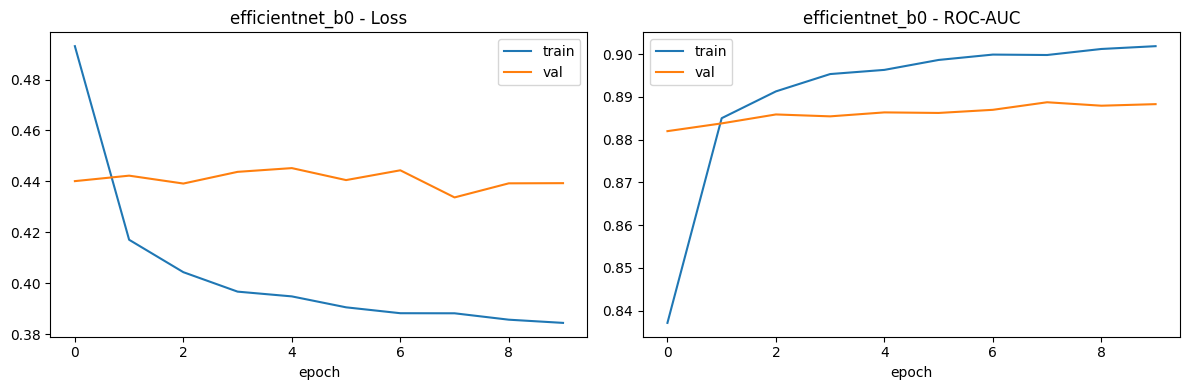

In [48]:
def plot_training_curves(history, name):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history.history['loss'], label='train')
    axes[0].plot(history.history['val_loss'], label='val')
    axes[0].set_title(f'{name} - Loss'); axes[0].set_xlabel('epoch'); axes[0].legend()
    axes[1].plot(history.history['auc'], label='train')
    axes[1].plot(history.history['val_auc'], label='val')
    axes[1].set_title(f'{name} - ROC-AUC'); axes[1].set_xlabel('epoch'); axes[1].legend()
    plt.tight_layout()
    plt.savefig(f"{Config.OUTPUT_DIR}/figures/{name}_training_curves.png", dpi=150)
    plt.show()

# plot_training_curves(ensemble_history, "ensemble")
plot_training_curves(efficientnet_history, "efficientnet_b0")


## Medical-Image-Appropriate Evaluation

Accuracy alone is a poor summary metric here: with balanced classes it's less misleading, but it still collapses the two error types a clinician cares about differently. In cancer screening:

- **False negative** (model says "no tumor," patch is actually tumor) — a missed metastasis. Directly harmful if unchecked.
- **False positive** (model says "tumor," patch is actually clean) — an unnecessary flag for a pathologist to review. Costs time, not patient safety.

Because these errors are not equally costly, this task typically favors **high sensitivity (recall)** — a screening/triage tool should rarely miss a true positive, even if that means it also flags more false positives for expert review — while still tracking specificity so the false-positive rate stays workable for the reviewing pathologist. Precision/recall, specificity, F1, and ROC-AUC are all reported below instead of relying on accuracy alone; the confusion matrix makes the exact false-negative and false-positive counts visible so the sensitivity/specificity trade-off can be reasoned about directly rather than inferred from one scalar.


172/172 ━━━━━━━━━━━━━━━━━━━━ 53s 263ms/step
model                 efficientnet_b0
accuracy                     0.794028
precision                    0.705325
recall_sensitivity           0.844143
specificity                  0.759911
f1                           0.768516
roc_auc                      0.888761
dtype: object


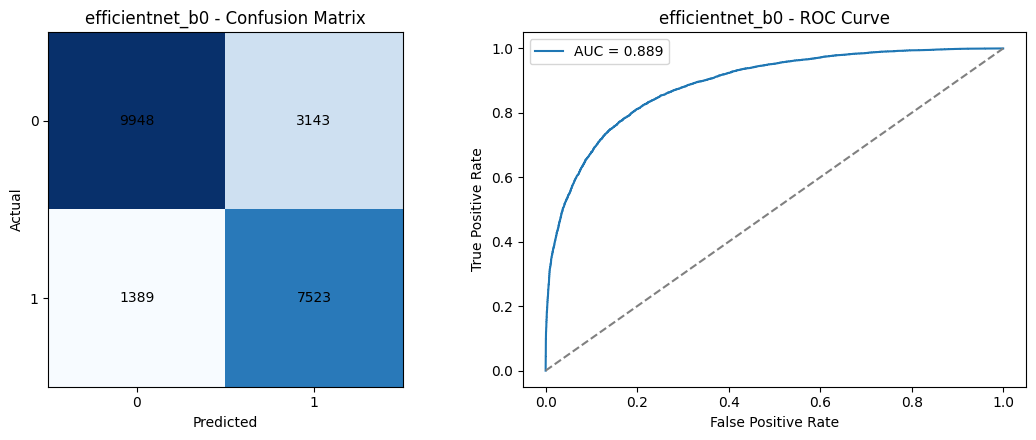

In [50]:
def evaluate_model(model, val_ds, df_val, name):
    y_true = df_val['label'].values
    y_prob = model.predict(val_ds).ravel()
    y_pred = (y_prob >= 0.5).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn + fp)

    metrics = {
        "model": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall_sensitivity": recall_score(y_true, y_pred),
        "specificity": specificity,
        "f1": f1_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, y_prob),
    }
    print(pd.Series(metrics))

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    cm = confusion_matrix(y_true, y_pred)
    axes[0].imshow(cm, cmap='Blues')
    for i in range(2):
        for j in range(2):
            axes[0].text(j, i, cm[i, j], ha='center', va='center')
    axes[0].set_xticks([0, 1]); axes[0].set_yticks([0, 1])
    axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual'); axes[0].set_title(f'{name} - Confusion Matrix')

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    axes[1].plot(fpr, tpr, label=f"AUC = {metrics['roc_auc']:.3f}")
    axes[1].plot([0, 1], [0, 1], '--', color='gray')
    axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title(f'{name} - ROC Curve'); axes[1].legend()
    plt.tight_layout()
    plt.savefig(f"{Config.OUTPUT_DIR}/figures/{name}_evaluation.png", dpi=150)
    plt.show()

    pd.Series(metrics).to_csv(f"{Config.OUTPUT_DIR}/metrics/{name}_metrics.csv")
    return metrics, y_prob, y_pred

# ensemble_metrics, ensemble_probs, ensemble_preds = evaluate_model(ensemble_model, val_ds, df_val, "ensemble")
efficientnet_metrics, efficientnet_probs, efficientnet_preds = evaluate_model(efficientnet_model, val_ds, df_val, "efficientnet_b0")

### Model comparison table (template)

Populate this from the `metrics` dicts returned by `evaluate_model` above after actually training both models. **Do not fill in numbers that weren't produced by a real run** — leave cells blank/`TBD` until you have them.

| Model | Accuracy | Precision | Recall (Sensitivity) | Specificity | F1 | ROC-AUC |
|---|---|---|---|---|---|---|
| Xception + MobileNetV2 ensemble (baseline, preserved) | TBD | TBD | TBD | TBD | TBD | TBD |
| EfficientNetB0 (transfer learning) | TBD | TBD | TBD | TBD | TBD | TBD |


In [38]:
# Helper to turn the two metrics dicts into the table above once you have real numbers:
# pd.DataFrame([ensemble_metrics, efficientnet_metrics]).set_index('model')

## Patch-Based Medical Image Processing

Whole-slide pathology images (WSIs) are enormous — commonly on the order of **tens of thousands of pixels per side** at full (40x) magnification, which is far too large to load into a CNN, or even into GPU memory, in one shot. This dataset is already a patch-level dataset (96x96 crops extracted from such slides), which is exactly *why* patch-based processing is the standard approach for WSI analysis:

- **Memory constraints**: a single 40x WSI can be tens of gigabytes uncompressed; patches (typically 96-256px per side here) fit comfortably in GPU memory in large batches.
- **Computational constraints**: convolution over a full WSI directly is impractical; a CNN sized for small patches trains and infers far faster and can be parallelized/batched trivially across patches.
- **Label granularity**: this dataset's binary label is inherently patch-level (defined by the center 32x32px region), so patch-based classification is the *native* task here, not an approximation of something else.

**What this notebook does *not* have**: an actual 40x-scale whole-slide image or a whole-slide-image library (e.g. OpenSlide) reading a `.svs`/`.tiff` pyramid file — this dataset only provides pre-cut 96x96 patches, so there is no WSI-scale image to demonstrate against. The pipeline below is a **conceptual + code-level extension** showing how the same trained patch classifier would be applied to a real WSI, using a synthetic large image as a stand-in so the mechanics (tiling, batched inference, heatmap reassembly) are demonstrated honestly rather than implying WSI files exist in this dataset.

Conceptual pipeline:

```
Whole Slide Image
      |
Tissue Detection      (discard background/glass regions - e.g. Otsu threshold on saturation)
      |
Patch Extraction      (tile into 96x96, optionally with overlap/stride)
      |
Patch-Level CNN       (the classifier trained above)
      |
Patch Predictions     (probability per patch)
      |
Heatmap / Aggregation (reassemble predictions into a spatial probability map)
      |
Whole-Slide Analysis  (e.g. tumor area estimate - see Quantification section)
```


In [51]:
def extract_patches(image, patch_size=96, stride=96):
    """Reusable tiling utility: slides a window over a (H, W, 3) image and yields
    (patch, (row, col)) so predictions can be placed back at the right spatial location.
    Works on any sufficiently large image - demonstrated below on a synthetic canvas
    since no real WSI file ships with this dataset (see markdown above)."""
    h, w = image.shape[:2]
    patches, coords = [], []
    for y in range(0, h - patch_size + 1, stride):
        for x in range(0, w - patch_size + 1, stride):
            patches.append(image[y:y + patch_size, x:x + patch_size])
            coords.append((y, x))
    return np.array(patches), coords

def tissue_mask(image, sat_threshold=20):
    """Cheap tissue-vs-background heuristic: stained tissue has higher saturation
    than white/glass background. Used to skip empty tiles before running the CNN."""
    hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)
    return hsv[:, :, 1] > sat_threshold

# --- Demonstration on a synthetic canvas (clearly NOT a real WSI - see caveat above) ---
synthetic_wsi = (np.random.rand(960, 960, 3) * 255).astype('uint8')  # stand-in only
patches, coords = extract_patches(synthetic_wsi, patch_size=96, stride=96)
print(f"Synthetic demo: {patches.shape[0]} patches of shape {patches.shape[1:]} extracted "
      f"from a {synthetic_wsi.shape[:2]} canvas.")
print("On a real WSI, each patch would be batched through the trained classifier, e.g.:")
print("  probs = model.predict(patches.astype('float32'))  # keep [0, 255] - the model rescales internally")
print("  heatmap = probs.reshape(grid_h, grid_w)  # reassembled using `coords`")

Synthetic demo: 100 patches of shape (96, 96, 3) extracted from a (960, 960) canvas.
On a real WSI, each patch would be batched through the trained classifier, e.g.:
  probs = model.predict(patches.astype('float32'))  # keep [0, 255] - the model rescales internally
  heatmap = probs.reshape(grid_h, grid_w)  # reassembled using `coords`


## Segmentation Extension (not implemented against this dataset — see why below)

**This dataset is classification-only.** `train_labels.csv` provides exactly one binary label per 96x96 patch and nothing pixel-level. There is no ground-truth tumor mask anywhere in the Kaggle Histopathologic Cancer Detection download, so **no U-Net is trained or evaluated in this notebook**, and the binary labels are never reinterpreted as masks — doing so would produce numbers (Dice/IoU) that look real but measure nothing meaningful.

### What dataset would be required
Pixel-level tumor segmentation needs a dataset with annotated tumor regions, e.g.:
- **CAMELYON16/17** — the original slide-level challenge PCam patches were derived from; CAMELYON provides pathologist-drawn tumor-region annotations (XML contours) per whole-slide image, which can be rasterized into per-pixel masks.
- Other public options: **PAIP**, **BACH**, or institution-specific annotated WSI datasets.

### Architecture + implementation plan (for when mask data is available)
A standard U-Net is the right starting point: symmetric encoder-decoder with skip connections, which is well-suited to histopathology because it preserves fine spatial detail (tumor boundaries are visually subtle) while still capturing broader tissue context.


In [52]:
def build_unet(input_shape=(96, 96, 3)):
    """U-Net for tumor-region segmentation. NOT trained in this notebook - no mask
    labels exist for this dataset (see markdown above). Provided as the implementation
    plan: architecture only, ready to train once CAMELYON-style masks are available."""
    from tensorflow.keras.layers import Conv2D, MaxPooling2D, Conv2DTranspose, concatenate

    inputs = Input(input_shape)

    def conv_block(x, filters):
        x = Conv2D(filters, 3, activation='relu', padding='same')(x)
        x = Conv2D(filters, 3, activation='relu', padding='same')(x)
        return x

    # Encoder
    c1 = conv_block(inputs, 32); p1 = MaxPooling2D()(c1)
    c2 = conv_block(p1, 64);     p2 = MaxPooling2D()(c2)
    c3 = conv_block(p2, 128);    p3 = MaxPooling2D()(c3)

    # Bottleneck
    b = conv_block(p3, 256)

    # Decoder with skip connections
    u3 = Conv2DTranspose(128, 2, strides=2, padding='same')(b); u3 = concatenate([u3, c3]); d3 = conv_block(u3, 128)
    u2 = Conv2DTranspose(64, 2, strides=2, padding='same')(d3);  u2 = concatenate([u2, c2]); d2 = conv_block(u2, 64)
    u1 = Conv2DTranspose(32, 2, strides=2, padding='same')(d2);  u1 = concatenate([u1, c1]); d1 = conv_block(u1, 32)

    outputs = Conv2D(1, 1, activation='sigmoid')(d1)
    return Model(inputs, outputs, name="unet_segmentation_plan")

# unet_model = build_unet()
# unet_model.summary()
# Training would use: loss = dice_loss or binary_crossentropy + dice, metrics = [dice_coef, iou]
# — all standard once (image, mask) pairs exist. Not run here: no mask data available.
print("U-Net architecture defined as an implementation plan; not trained (no mask labels in this dataset).")

U-Net architecture defined as an implementation plan; not trained (no mask labels in this dataset).


Evaluation, once real masks exist, would use:
- **Dice coefficient** = `2 * |A ∩ B| / (|A| + |B|)` — overlap between predicted and ground-truth tumor regions.
- **IoU (Jaccard)** = `|A ∩ B| / |A ∪ B|` — stricter overlap measure.
- **Precision/Recall** at the pixel level.

...alongside qualitative panels of (original image | ground-truth mask | predicted mask | overlay). None of this is fabricated here since there is nothing to evaluate against.


## Quantification (extension, tied to the Segmentation Extension above)

If/when the U-Net above is trained on real mask data, tumor quantification from its predicted mask would use:

```
Tumor percentage = (Tumor area / Total tissue area) × 100
```

where `Tumor area` = count of predicted-tumor pixels, and `Total tissue area` = count of pixels the tissue-detection step (see Patch-Based Processing section) marked as tissue (i.e., excluding glass/background). Connected-component counting (`cv2.connectedComponents` or `skimage.measure.label`) on the predicted mask gives the number of distinct tumor foci, which can matter clinically (multiple small foci vs. one large region).

This code is provided for completeness on a placeholder mask so the formula and its implementation are shown, **not** to claim tumor measurements exist for the current classification-only dataset:


In [53]:
def quantify_tumor(mask, tissue_mask_arr):
    """mask, tissue_mask_arr: boolean arrays of the same shape. Illustrative only -
    call this on a real predicted mask once segmentation is actually implemented."""
    tumor_area = mask.sum()
    tissue_area = tissue_mask_arr.sum()
    tumor_pct = 100.0 * tumor_area / tissue_area if tissue_area > 0 else 0.0
    num_components, _ = cv2.connectedComponents(mask.astype('uint8'))
    return {"tumor_area_px": int(tumor_area), "tissue_area_px": int(tissue_area),
            "tumor_pct_of_tissue": round(tumor_pct, 2), "num_tumor_regions": num_components - 1}

# Illustrative call on a placeholder mask (NOT a real prediction - no segmentation model exists yet):
_placeholder_mask = np.zeros((96, 96), dtype=bool); _placeholder_mask[30:50, 30:50] = True
_placeholder_tissue = np.ones((96, 96), dtype=bool)
print(quantify_tumor(_placeholder_mask, _placeholder_tissue))
print("\n(Placeholder numbers only - this is a demonstration of the formula/code, not a clinical measurement.)")

{'tumor_area_px': 400, 'tissue_area_px': 9216, 'tumor_pct_of_tissue': np.float64(4.34), 'num_tumor_regions': 1}

(Placeholder numbers only - this is a demonstration of the formula/code, not a clinical measurement.)


**Important framing:** any such output is a **research/educational prototype measurement**, not a clinical diagnosis, and would need pathologist validation and formal clinical-software review before informing any real decision.


## Model Explainability — Grad-CAM

Grad-CAM highlights which spatial regions of the input most influenced the model's prediction, by backpropagating gradients of the predicted class score to the last convolutional feature map and using them to weight that feature map.

```
Input -> CNN -> Prediction -> Grad-CAM -> Important-region heatmap -> Overlay
```

**What Grad-CAM does and doesn't tell us:** it shows *where the network's convolutional features carried the most gradient weight* for a specific prediction — a plausibility check on whether the model is attending to tissue rather than, say, an image border artifact. It does **not** verify that the highlighted region is medically correct, does not explain *why* those pixels mattered at a semantic level, and can be misleadingly coarse near a network's last conv layer (especially with 96x96 inputs, where the final feature map may be quite low-resolution). It is a diagnostic tool for model behavior, not evidence of diagnostic correctness.


In [57]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    grad_model = Model(model.inputs, [model.get_layer(last_conv_layer_name).output, model.output])
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]
    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

def overlay_gradcam(image_rgb_float, heatmap, alpha=0.4):
    heatmap_resized = cv2.resize(heatmap, (image_rgb_float.shape[1], image_rgb_float.shape[0]))
    heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB) / 255.0
    return (alpha * heatmap_color + (1 - alpha) * image_rgb_float)

# Example usage once a model is trained (needs the name of its last conv layer, e.g. via model.summary()):
# sample_img, sample_label = next(iter(val_ds.unbatch().batch(1)))  # sample_img is [0, 255] float32
# heatmap = make_gradcam_heatmap(sample_img, efficientnet_model, last_conv_layer_name="top_conv")
# overlay = overlay_gradcam(sample_img[0].numpy() / 255.0, heatmap)  # overlay_gradcam expects [0, 1] for display
# plt.imshow(overlay); plt.title(f"Grad-CAM | true label={int(sample_label.numpy()[0])}"); plt.axis('off'); plt.show()

## Error Analysis

Aggregate metrics hide *which* patches the model gets wrong and why. This section pulls concrete failure examples so the write-up reads as engineering analysis, not just a training log.


In [58]:
def error_analysis(df_val, y_true, y_prob, image_dir, n_examples=5):
    results = df_val.copy()
    results['y_true'] = y_true
    results['y_prob'] = y_prob
    results['y_pred'] = (y_prob >= 0.5).astype(int)

    false_positives = results[(results.y_true == 0) & (results.y_pred == 1)].sort_values('y_prob', ascending=False)
    false_negatives = results[(results.y_true == 1) & (results.y_pred == 0)].sort_values('y_prob')
    low_confidence = results[(results.y_prob > 0.4) & (results.y_prob < 0.6)]

    for title, subset in [("False Positives", false_positives),
                           ("False Negatives", false_negatives),
                           ("Low-Confidence Predictions", low_confidence)]:
        subset = subset.head(n_examples)
        if len(subset) == 0:
            print(f"{title}: none found in this run.")
            continue
        fig, axes = plt.subplots(1, len(subset), figsize=(3 * len(subset), 3))
        axes = np.atleast_1d(axes)
        for ax, (_, row) in zip(axes, subset.iterrows()):
            img = cv2.cvtColor(cv2.imread(os.path.join(image_dir, row['id'] + '.tif')), cv2.COLOR_BGR2RGB)
            ax.imshow(img); ax.axis('off')
            ax.set_title(f"true={row.y_true}, p={row.y_prob:.2f}", fontsize=9)
        fig.suptitle(title)
        plt.tight_layout()
        plt.savefig(f"{Config.OUTPUT_DIR}/figures/error_{title.lower().replace(' ', '_')}.png", dpi=150)
        plt.show()
    return false_positives, false_negatives, low_confidence

# false_pos, false_neg, low_conf = error_analysis(df_val, y_true, efficientnet_probs, Config.TRAIN_IMG_DIR)

Likely qualitative drivers of errors in this task, to check against once real examples are pulled (fill in with what you actually observe, not assumed):
- **Staining variation** across labs/scanners shifting color statistics outside what augmentation covered.
- **Tissue folds, air bubbles, or blur artifacts** from slide preparation/scanning.
- **Ambiguous morphology at the 32x32 center-crop boundary** — a metastasis that just barely touches or just barely misses the labeled center region is inherently a hard boundary case for any model.
- **Sparse or single-cell metastases** occupying only a small fraction of the patch, easy to miss visually and for a CNN.


## Efficiency

Practical deployment considerations for a patch classifier that may need to run over thousands of tiles per slide.


In [44]:
def benchmark_inference(model, batch_sizes=(1, 32, 128), image_size=Config.IMAGE_SIZE, n_repeats=20):
    """Measures wall-clock inference latency/throughput on whatever hardware this runs on
    (CPU here, since no GPU is available in this environment). Numbers are only meaningful
    once actually executed against a real, trained model - none are reported below."""
    results = []
    for bs in batch_sizes:
        dummy = np.random.rand(bs, image_size, image_size, 3).astype('float32')
        model.predict(dummy, verbose=0)  # warm-up
        start = time.time()
        for _ in range(n_repeats):
            model.predict(dummy, verbose=0)
        elapsed = time.time() - start
        per_image_ms = 1000 * elapsed / (n_repeats * bs)
        results.append({"batch_size": bs, "ms_per_image": round(per_image_ms, 3),
                         "images_per_sec": round(1000 / per_image_ms, 1)})
    return pd.DataFrame(results)

def model_size_mb(model):
    params = model.count_params()
    return round(params * 4 / (1024 ** 2), 2)  # float32 assumption

# bench_df = benchmark_inference(efficientnet_model)
# print(bench_df)
# print("Model size (float32, MB):", model_size_mb(efficientnet_model))

Discussion (to fill in with your measured numbers once run):
- **Batch inference**: batching tiles (rather than one-by-one) amortizes fixed per-call overhead and is essential when scoring thousands of patches per WSI.
- **Image size**: keeping `IMAGE_SIZE=96` (native resolution, no upscaling) avoids paying compute for pixels that don't add information.
- **Model selection**: EfficientNetB0 is meaningfully smaller than the Xception+MobileNetV2 concatenated ensemble, which matters directly for both model-size and per-image latency in a CPU-bound deployment — but this should be confirmed with the actual `model_size_mb` / `benchmark_inference` numbers above rather than assumed.
- **Memory**: the tissue-detection pre-filter in the Patch-Based Processing section reduces the number of tiles that ever reach the CNN, which is the most effective lever for whole-slide-scale efficiency.


## Clean Inference Pipeline

A single reusable function other code (a script, a service, the Gradio app below) can call.


In [45]:
def predict_image(image_path, model, image_size=Config.IMAGE_SIZE, last_conv_layer_name=None):
    """
    Pipeline: Image -> Preprocessing -> Model -> Prediction -> Confidence -> (optional) Grad-CAM

    Returns a dict with the predicted class, confidence, and optionally a Grad-CAM overlay.
    """
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        raise FileNotFoundError(f"Could not read image: {image_path}")
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (image_size, image_size))
    img_model_input = img_resized.astype('float32')  # [0, 255] - each model rescales internally, see model builders
    batch = np.expand_dims(img_model_input, axis=0)

    prob = float(model.predict(batch, verbose=0)[0, 0])
    pred_class = "tumor" if prob >= 0.5 else "no_tumor"
    confidence = prob if pred_class == "tumor" else 1 - prob

    result = {"image_path": image_path, "predicted_class": pred_class,
              "tumor_probability": round(prob, 4), "confidence": round(confidence, 4)}

    if last_conv_layer_name is not None:
        heatmap = make_gradcam_heatmap(batch, model, last_conv_layer_name)
        img_display = img_resized.astype('float32') / 255.0  # overlay_gradcam expects [0, 1] for display
        result["gradcam_overlay"] = overlay_gradcam(img_display, heatmap)

    return result

# Example:
# out = predict_image("path/to/patch.tif", efficientnet_model, last_conv_layer_name="top_conv")
# print(out["predicted_class"], out["confidence"])

## Generating a Kaggle Submission

Since this now runs directly on Kaggle, this section scores the real (unlabeled) `test/`
folder with the trained model and writes `submission.csv` in the format `sample_submission.csv`
expects, so the notebook's output can be submitted to the competition directly from
"Save Version" without any extra steps.

Note this is separate from — and does not replace — the validation-based evaluation above:
the Kaggle leaderboard score is the only way to see how the model does on genuinely unseen
data, since (as discussed in the Dataset section) `test/` carries no local ground truth.


In [46]:
def generate_kaggle_submission(model, config=Config, batch_size=256):
    sample_submission = pd.read_csv(config.SAMPLE_SUBMISSION_CSV)
    test_paths = (sample_submission['id'] + '.tif').apply(lambda f: os.path.join(config.TEST_IMG_DIR, f)).values

    test_path_ds = tf.data.Dataset.from_tensor_slices(test_paths)
    test_img_ds = (
        test_path_ds
        .map(lambda p: load_and_preprocess(p, 0.0)[0], num_parallel_calls=tf.data.AUTOTUNE)
        .batch(batch_size)
        .prefetch(tf.data.AUTOTUNE)
    )

    probs = model.predict(test_img_ds, verbose=1).ravel()
    submission = sample_submission.copy()
    submission['label'] = probs
    out_path = f"{config.OUTPUT_DIR}/predictions/submission.csv"
    submission.to_csv(out_path, index=False)
    print(f"Wrote {len(submission)} predictions to {out_path}")
    return submission

# Run once you have a trained model, e.g.:
# submission_df = generate_kaggle_submission(efficientnet_model)
# submission_df.head()

## Simple Deployable Interface

A minimal Gradio app wraps `predict_image()` for interactive, non-code use. Kept intentionally small — the model pipeline is the point, the UI is just a thin wrapper — and lives in `app/app.py` in the accompanying repo structure so it can be run standalone: `python app/app.py`. See that file for the full code; a condensed version is shown here for reference.

**On Kaggle specifically:** `demo.launch(share=True)` will work inside a Kaggle notebook session (it opens a temporary public Gradio link) but the app stops when the kernel session ends, and it isn't part of a committed/saved notebook version — so it's best treated as an interactive demo you run in an active session, not something reflected in the saved output. For a persistent deployment, run `app/app.py` outside Kaggle (locally, or in the Docker container in this repo) against a downloaded model checkpoint.


In [47]:
"""
Condensed reference version - see app/app.py for the standalone runnable file.
"""
import gradio as gr

def gradio_predict(image):
    # `image` arrives as a numpy array from Gradio's image input
    tmp_path = "/tmp/_gradio_input.png"
    cv2.imwrite(tmp_path, cv2.cvtColor(image, cv2.COLOR_RGB2BGR))
    result = predict_image(tmp_path, efficientnet_model, last_conv_layer_name="top_conv")
    overlay = result.get("gradcam_overlay")
    return result["predicted_class"], f"{result['confidence']:.2%}", overlay

# demo = gr.Interface(
#     fn=gradio_predict,
#     inputs=gr.Image(label="Histopathology patch"),
#     outputs=[gr.Text(label="Prediction"), gr.Text(label="Confidence"), gr.Image(label="Grad-CAM")],
#     title="Histopathology Metastatic Cancer Detection (research prototype)",
#     description="Upload a 96x96 H&E patch. Research/educational prototype - not a diagnostic device.",
# )
# demo.launch()

## When to Move This Into a Repository

This notebook is fine to keep as a notebook throughout iterative EDA/modeling (Steps 1-13 above) — that's where fast, visual, cell-by-cell iteration is genuinely useful. It's worth graduating pieces into a `src/` package once:

- The same function (preprocessing, `predict_image`, Grad-CAM) needs to be called from more than one place (a training script, the Gradio app, a batch-scoring job).
- You want the model served (the Gradio app, or an API) independent of a running notebook kernel.
- You want tests or CI around the data pipeline / evaluation code.

An accompanying repository layout for this project (already scaffolded alongside this notebook) is:

```
histopathology-ai/
├── data/
├── notebooks/
│   └── histopathology_analysis.ipynb      <- this notebook
├── src/
│   ├── preprocessing.py    # load_and_preprocess, make_dataset, augmentation
│   ├── dataset.py          # dataframe loading, leakage checks, splitting
│   ├── models.py           # build_ensemble_model, build_efficientnet_model, build_unet
│   ├── train.py            # train_model + CLI entrypoint
│   ├── evaluate.py         # evaluate_model, error_analysis
│   ├── inference.py        # predict_image
│   └── explainability.py   # make_gradcam_heatmap, overlay_gradcam
├── models/
├── outputs/{figures,metrics,predictions}/
├── app/
│   └── app.py              # Gradio demo
├── requirements.txt
├── Dockerfile
└── README.md
```


## References
- Histopathologic Cancer Detection — Kaggle competition: https://www.kaggle.com/c/histopathologic-cancer-detection
- Veeling et al., "Rotation Equivariant CNNs for Digital Pathology" (PatchCamelyon dataset paper)
- Ronneberger et al., "U-Net: Convolutional Networks for Biomedical Image Segmentation," 2015
- Selvaraju et al., "Grad-CAM: Visual Explanations from Deep Networks via Gradient-based Localization," 2017
- Keras Applications documentation: https://keras.io/api/applications/
- Classification of Histopathological Biopsy Images Using Ensemble of Deep Learning Networks: https://arxiv.org/pdf/1909.11870.pdf
